# Does self-attention actually capture context effects? — CDM synthetic test (sweeps + upgraded metrics)

This notebook builds a synthetic choice dataset from a **Context Dependent Model (CDM)** where the true context effect is known exactly, then tests how much of that effect a flexible **self-attention** model actually recovers — **across dataset size, number of features, and transformer depth.**

**The logic in one line:** plant a known pairwise context effect → confirm a correctly-specified model recovers it perfectly (the ceiling) → measure how much the attention model recovers → sweep the conditions → plot how recovery changes.

**What's new vs the first version.** The old "slope" probe reads the model's raw logit shifts, and those shifts have an **arbitrary scale** (softmax only cares about logit *differences*, so a model can shrink its whole utility axis without changing any prediction). So "recovers 46%" can't tell apart *learned half the effect* from *learned the whole effect on a squashed scale*. We therefore add two scale-robust metrics:

- **NLL gap vs the yardstick** (Protocol 1) — how much predictive information the attention model fails to extract, on a fixed nats scale. This is the number every paper in this area reports.
- **IIA ratio-shift recovery** (Protocol 2) — measures a *ratio* of two items' probabilities as a third item is added/removed. Ratios cancel the logit scale, so this metric can't be fooled the way the slope was. It's the same difference-in-differences instinct, grounded in the IIA definition of a context effect.

We keep the **old slope** in as a third line labelled *(old probe, scale-confounded)* so the upgrade is visible.


## 1. Imports and softmax helper

We only need `numpy` and `pandas` to build the dataset. The `softmax` turns a set of item utilities into choice probabilities that sum to 1 — the max-subtraction is just for numerical stability (stops `exp` from overflowing). This is the function that converts "how good is each item" into "how likely is each item to be clicked".


In [1]:
import numpy as np
import pandas as pd

def softmax(u):
    u = u - np.max(u)
    e = np.exp(u)
    return e / e.sum()

## 2. The CDM data generator

This is the heart of the synthetic setup. For every item *i* in a slate *S* the utility is:

$$U(i, S) = \theta^\top x_i \;+\; \sum_{j \in S,\, j \neq i} x_j^\top C\, x_i$$

- The first term $\theta^\top x_i$ is the plain MNL part — how appealing the item is on its own features.
- The second term is the **CDM context effect**: every *other* item *j* in the slate pushes on *i* through the interaction matrix **C**. This is a sum of *pairwise* pushes, which is exactly what a set-average (LCL) cannot reproduce.

`context_strength` is the single knob: set it to 0 and **C** vanishes, giving pure MNL with no context effect (our baseline). The matrix **C** is drawn once from a fixed RNG (seed 12345) so the ground truth is identical every run **for a given feature count**. Because we now sweep `n_features`, **C** is a `d×d` matrix whose size grows with `d` — a bigger `d` means more interaction entries to pin down from the same data, which stresses *identification*. We then softmax the utilities and sample one winner per slate.

**Note on the θ default:** with more features we can't hand-write θ, so for `d>3` we tile the base pattern and pad with small values so every feature carries some own-utility signal.


In [2]:
# Model, for item i in slate S:
#     U(i, S) = theta . x_i  +  sum_{j != i} x_j^T C x_i
# Knob: context_strength=0 -> C=0 -> pure MNL baseline (no context).
#
# FIX (feature-count sweep confound): both C and theta are now normalised to a
# FIXED norm regardless of d, so the true effect magnitude stays comparable as
# n_features grows. Previously C was raw N(0,1) (Frobenius norm ~d) and theta
# had a d>3 special case (*0.8) -> the sweep was confounding "harder to
# identify" with "the planted effect itself got bigger". Now only d changes.
def generate_cdm_data(n_sessions=8000, n_features=3, slate_size=5,
                      theta=None, C=None, context_strength=1.0,
                      feature_scale=1.0, seed=0):
    rng = np.random.default_rng(seed)
    d = n_features

    if theta is None:
        base = np.array([-1.0, 1.0, 0.5])
        reps = int(np.ceil(d / 3))
        theta = np.tile(base, reps)[:d]
        theta = theta / np.linalg.norm(theta) * np.linalg.norm(base)  # hold ||theta|| fixed
    theta = np.asarray(theta, dtype=float)

    if C is None:
        c_rng = np.random.default_rng(12345)   # fixed -> reproducible C (per d)
        C_raw = c_rng.normal(0.0, 1.0, size=(d, d))
        C = C_raw / np.linalg.norm(C_raw)      # unit Frobenius norm, any d
    C = np.asarray(C, dtype=float)
    C_eff = context_strength * C

    rows = []
    for s in range(n_sessions):
        X = rng.normal(0.0, feature_scale, size=(slate_size, d))
        U = X @ theta
        M = X @ C_eff @ X.T                       # M[j,i] = x_j^T C x_i
        context = M.sum(axis=0) - np.diag(M)      # sum over j != i
        U = U + context
        P = softmax(U)
        chosen_idx = rng.choice(slate_size, p=P)
        for i in range(slate_size):
            row = {"session_id": s, "item_in_slate": i}
            for f in range(d):
                row[f"feat_{f}"] = X[i, f]
            row["chosen"] = int(i == chosen_idx)
            rows.append(row)

    df = pd.DataFrame(rows)
    gt = {"theta": theta, "C": C_eff, "n_features": d,
          "slate_size": slate_size, "context_strength": context_strength}
    return df, gt

## 3. Generate a reference pair of datasets (default config)

We first generate one **effect / baseline** pair at the default config (8,000 sessions, 3 features, slate 5) exactly like the original notebook, to sanity-check the pipeline before sweeping. Later cells regenerate data inside the sweep loops.

- `df_ctx` — the **effect** dataset, `context_strength=1.0`, so **C ≠ 0** (real context effects).
- `df_base` — the **baseline** dataset, `context_strength=0.0`, so **C = 0** (no context).

This prints the ground-truth θ and **C** — the numbers everything downstream is checked against.


In [3]:
df_ctx,  gt_ctx  = generate_cdm_data(context_strength=1.0, seed=0)  # C != 0
df_base, gt_base = generate_cdm_data(context_strength=0.0, seed=0)  # C  = 0

print("theta:", np.round(gt_ctx["theta"], 3))
print("C (ground-truth interaction matrix):")
print(np.round(gt_ctx["C"], 3))
print("effect shape:", df_ctx.shape, "| sessions:", df_ctx.session_id.nunique())
df_ctx.head(10)

theta: [-1.   1.   0.5]
C (ground-truth interaction matrix):
[[-0.522  0.464 -0.319]
 [-0.095 -0.028 -0.272]
 [-0.502  0.238  0.132]]
effect shape: (40000, 6) | sessions: 8000


,session_id,item_in_slate,feat_0,feat_1,feat_2,chosen
0,0,0,0.125730,-0.132105,0.640423,1
1,0,1,0.104900,-0.535669,0.361595,0
2,0,2,1.304000,0.947081,-0.703735,0
3,0,3,-1.265421,-0.623274,0.041326,0
4,0,4,-2.325031,-0.218792,-1.245911,0
5,1,0,-0.544259,-0.316300,0.411631,0
6,1,1,1.042513,-0.128535,1.366463,1
7,1,2,-0.665195,0.351510,0.903470,0
8,1,3,0.094012,-0.743499,-0.921725,0
9,1,4,-0.457726,0.220195,-1.009618,0


## 4. Set up PyTorch

Import torch and pick the device (GPU if available, else CPU). On Colab/Kaggle, switch the runtime to a GPU — the sweeps train many models, so a GPU cuts the wall-clock a lot.


In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


## 5. Collate: long dataframe → padded slate tensors

The model consumes whole slates, not individual rows. This groups the long dataframe by `session_id` and stacks each slate into tensors:
- `X` — item features, shape `(n_slates, max_slate, n_features)`
- `y` — a 1 marking the chosen item in each slate
- `mask` — marks which entries are real items (vs padding)

Now takes `n_features` as an argument so it works for any feature count in the sweep.


In [5]:
def collate_slates(df, n_features=3):
    """Long-format df (one row per item) -> slate-batched padded tensors."""
    feat_cols = [f"feat_{f}" for f in range(n_features)]
    groups = list(df.groupby("session_id"))
    n_slates = len(groups)
    max_slate = df.groupby("session_id").size().max()

    X    = torch.zeros(n_slates, max_slate, n_features)
    y    = torch.zeros(n_slates, max_slate)
    mask = torch.zeros(n_slates, max_slate, dtype=torch.bool)

    for s, (_, g) in enumerate(groups):
        g = g.sort_values("item_in_slate")
        k = len(g)
        X[s, :k]    = torch.tensor(g[feat_cols].values, dtype=torch.float32)
        y[s, :k]    = torch.tensor(g["chosen"].values,  dtype=torch.float32)
        mask[s, :k] = True

    return X, y, mask

## 6. Train/test split

An 80/20 split into train and test, applied identically to the effect and baseline datasets so the C=0 control stays a clean parallel.


In [6]:
def train_test_split_slates(X, y, mask, frac=0.8, seed=0):
    n = X.shape[0]
    g = torch.Generator().manual_seed(seed)
    perm = torch.randperm(n, generator=g)
    n_train = int(frac * n)
    tr, te = perm[:n_train], perm[n_train:]
    return (X[tr], y[tr], mask[tr]), (X[te], y[te], mask[te])

## 7. The self-attention choice model

This is the flexible model whose recovery we want to test. Each item is embedded, then passed through a `TransformerEncoder` so **every item can attend to every other item in the slate** — giving it the architectural capacity to represent cross-item context effects. A final linear layer scores each item; padded slots are masked to −∞ before the softmax.

`n_features` and `n_layers` are both arguments now, because we sweep them. With even 1–2 layers this model has *far* more capacity than the true C matrix — so if it under-recovers, that's an *identification* failure, not a capacity limit.


In [7]:
class AttentionChoiceModel(nn.Module):
    def __init__(self, n_features=3, d_model=32, n_heads=4, n_layers=2, ff=64):
        super().__init__()
        self.embed = nn.Linear(n_features, d_model)
        layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads,
            dim_feedforward=ff, batch_first=True, dropout=0.0)
        self.encoder = nn.TransformerEncoder(layer, num_layers=n_layers)
        self.score = nn.Linear(d_model, 1)

    def forward(self, X, mask):
        h = self.embed(X)                          # (B, S, d)
        pad = ~mask                                # True = padding to ignore
        h = self.encoder(h, src_key_padding_mask=pad)
        logits = self.score(h).squeeze(-1)         # (B, S)
        logits = logits.masked_fill(pad, float("-inf"))
        return logits

## 8. The CDM yardstick model

This is the **correctly-specified** model: it learns θ and **C** directly and computes utilities with the *exact same formula* the generator used (`x_j^T C x_i` summed over neighbours, via einsum). It has only `d + d²` parameters.

Because its form matches the truth, it *should* recover **C** almost perfectly — this is our ceiling and the reference for both the NLL gap and the recovery metrics.


In [8]:
class CDMChoiceModel(nn.Module):
    """Correctly-specified CDM. Learns theta (F,) and C (F,F) directly.
    Utility for item i:  theta . x_i + sum_{j!=i} x_j^T C x_i . The recovery ceiling."""
    def __init__(self, n_features=3):
        super().__init__()
        self.theta = nn.Parameter(torch.zeros(n_features))
        self.C     = nn.Parameter(torch.zeros(n_features, n_features))

    def forward(self, X, mask):
        base = X @ self.theta                      # (B, S)
        XC = X @ self.C                            # (B, S, F)
        M  = torch.einsum("bjf,bif->bji", XC, X)   # (B, S, S), M[b,j,i]=x_j^T C x_i
        realj = mask.unsqueeze(-1).float()
        Msum  = (M * realj).sum(dim=1)             # sum over j -> (B, S)
        diag  = torch.diagonal(M, dim1=1, dim2=2)  # remove j==i
        context = Msum - diag
        logits = (base + context).masked_fill(~mask, float("-inf"))
        return logits

## 9. The training loop

Standard listwise choice training: for each slate, softmax over the item logits and apply cross-entropy against the index of the truly chosen item. Returns the trained model and its **final test NLL** (mean cross-entropy on the held-out slates) — that test NLL is exactly Protocol-1's currency, so we return it rather than just printing it.

`verbose=False` keeps the sweep output quiet.


In [9]:
def train_model(model, Xtr, ytr, mtr, Xte, yte, mte,
                epochs=30, lr=1e-3, batch=256, seed=0, verbose=True):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    Xtr, ytr, mtr = Xtr.to(device), ytr.to(device), mtr.to(device)
    Xte, yte, mte = Xte.to(device), yte.to(device), mte.to(device)

    target_tr = ytr.argmax(dim=1)
    target_te = yte.argmax(dim=1)
    n = Xtr.shape[0]
    g = torch.Generator().manual_seed(seed)

    te_loss = float("nan")
    for ep in range(1, epochs + 1):
        model.train()
        perm = torch.randperm(n, generator=g)
        tot = 0.0
        for i in range(0, n, batch):
            idx = perm[i:i+batch]
            logits = model(Xtr[idx], mtr[idx])
            loss = F.cross_entropy(logits, target_tr[idx])
            opt.zero_grad(); loss.backward(); opt.step()
            tot += loss.item() * len(idx)
        model.eval()
        with torch.no_grad():
            te_logits = model(Xte, mte)
            te_loss = F.cross_entropy(te_logits, target_te).item()
            acc = (te_logits.argmax(1) == target_te).float().mean().item()
        if verbose and (ep % 5 == 0 or ep == 1):
            print(f"epoch {ep:2d} | train loss {tot/n:.4f} | "
                  f"test loss {te_loss:.4f} | test acc {acc:.3f}")
    return model, te_loss

## 10. Smoke test on the default config

Train the attention model and the yardstick once on the reference data to confirm the pipeline still behaves like the original notebook: attention accuracy ~0.81, yardstick recovering **C** with near-1.0 correlation, and — new — the **test NLL of each**, which is the raw material for the NLL-gap metric.


In [10]:
(Xtr_c, ytr_c, mtr_c), (Xte_c, yte_c, mte_c) = train_test_split_slates(
    *collate_slates(df_ctx, gt_ctx["n_features"]))

torch.manual_seed(0)
attn0, nll_attn0 = train_model(AttentionChoiceModel(n_features=gt_ctx["n_features"]),
                               Xtr_c, ytr_c, mtr_c, Xte_c, yte_c, mte_c, verbose=True)
torch.manual_seed(0)
cdm0, nll_cdm0 = train_model(CDMChoiceModel(n_features=gt_ctx["n_features"]),
                             Xtr_c, ytr_c, mtr_c, Xte_c, yte_c, mte_c,
                             epochs=100, lr=5e-2, verbose=False)

C_hat = cdm0.C.detach().cpu().numpy()
corr = np.corrcoef(gt_ctx["C"].flatten(), C_hat.flatten())[0, 1]
print(f"\nyardstick C correlation vs truth : {corr:.3f}")
print(f"attention test NLL               : {nll_attn0:.4f}")
print(f"yardstick test NLL (the floor)   : {nll_cdm0:.4f}")
print(f"NLL gap (attn - yardstick)       : {nll_attn0 - nll_cdm0:+.4f}   <- Protocol 1")

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


epoch  1 | train loss 1.3717 | test loss 1.2218 | test acc 0.536
epoch  5 | train loss 0.8794 | test loss 0.8724 | test acc 0.666
epoch 10 | train loss 0.8465 | test loss 0.8571 | test acc 0.681
epoch 15 | train loss 0.8303 | test loss 0.8512 | test acc 0.679
epoch 20 | train loss 0.8209 | test loss 0.8610 | test acc 0.674
epoch 25 | train loss 0.8120 | test loss 0.8584 | test acc 0.674
epoch 30 | train loss 0.8011 | test loss 0.8650 | test acc 0.676

yardstick C correlation vs truth : 0.996
attention test NLL               : 0.8650
yardstick test NLL (the floor)   : 0.8390
NLL gap (attn - yardstick)       : +0.0259   <- Protocol 1


## 11. Metric A — the OLD controlled-swap probe (kept as a comparison line)

This is the original diagnostic, unchanged in spirit. For each trial: freeze a target *i*, build two slates identical except one swapped neighbour, compute the true utility shift **Δ_true** from **C**, and measure the model's logit shift **Δ_attn**. The **slope** of Δ_attn on Δ_true is the "fraction recovered".

We keep it **only for comparison** — its weakness is that Δ_attn lives on the model's arbitrary logit scale, so the slope conflates *learned less* with *learned on a smaller scale*. Metrics B and C below fix that.


In [11]:
def swap_probe_slope(attn_model, C_true, n_features, slate_size=5,
                     n_trials=3000, seed=1):
    rng = np.random.default_rng(seed)
    attn_model.eval()
    C_true = np.asarray(C_true)
    d_true_all, d_attn_all = [], []
    with torch.no_grad():
        for _ in range(n_trials):
            x_i     = rng.normal(0, 1, size=n_features)
            fillers = rng.normal(0, 1, size=(slate_size - 2, n_features))
            x_jA    = rng.normal(0, 1, size=n_features)
            x_jB    = rng.normal(0, 1, size=n_features)
            d_true = (x_jB - x_jA) @ (C_true @ x_i)
            slateA = np.vstack([x_i, x_jA, fillers])
            slateB = np.vstack([x_i, x_jB, fillers])
            XA = torch.tensor(slateA, dtype=torch.float32, device=device).unsqueeze(0)
            XB = torch.tensor(slateB, dtype=torch.float32, device=device).unsqueeze(0)
            m  = torch.ones(1, slate_size, dtype=torch.bool, device=device)
            d_attn = attn_model(XB, m)[0, 0].item() - attn_model(XA, m)[0, 0].item()
            d_true_all.append(d_true); d_attn_all.append(d_attn)
    d_true_all = np.array(d_true_all); d_attn_all = np.array(d_attn_all)
    slope = np.polyfit(d_true_all, d_attn_all, 1)[0]
    corr  = np.corrcoef(d_true_all, d_attn_all)[0, 1]
    return slope, corr

## 12. Metric B — Protocol 1: held-out NLL gap vs the yardstick

The cheapest and most standard metric. The yardstick is correctly-specified, so its test NLL is the **best achievable** on this data (the floor). The gap

$$\text{NLL gap} = \text{NLL}_\text{attention} - \text{NLL}_\text{yardstick}$$

is how much predictive information the attention model **failed** to extract, on a fixed nats scale. It is scale-free by construction — it never asks "how big is the effect", only "how well do you predict". A gap near 0 means the attention model extracted essentially everything the correct model could; a positive gap is the shortfall.

This helper just trains both models on a given (already-split) dataset and returns the two test NLLs. (We already have `train_model` returning test NLL, so this is a thin wrapper used by the sweep.)


In [12]:
def nll_gap(Xtr, ytr, mtr, Xte, yte, mte, n_features, n_layers=2,
            seed=0, attn_epochs=30, yard_epochs=100):
    torch.manual_seed(seed)
    _, nll_attn = train_model(
        AttentionChoiceModel(n_features=n_features, n_layers=n_layers),
        Xtr, ytr, mtr, Xte, yte, mte, epochs=attn_epochs, seed=seed, verbose=False)
    torch.manual_seed(seed)
    _, nll_yard = train_model(
        CDMChoiceModel(n_features=n_features),
        Xtr, ytr, mtr, Xte, yte, mte, epochs=yard_epochs, lr=5e-2, seed=seed, verbose=False)
    return nll_attn, nll_yard

## 13. Metric C — Protocol 2: IIA ratio-shift recovery (the new headline)

A context effect **is**, by definition, a violation of IIA: the relative preference between two items A and B should not depend on the identity of a third neighbour. So we measure exactly that, using a **clean neighbour-swap** that keeps the slate size fixed (so the closed-form truth is exact, with no size confound).

For each trial:
1. Fix two items **A** and **B** and a set of fillers, at fixed slot positions.
2. Build two slates identical except that **one neighbour slot** holds $C^{(1)}$ vs $C^{(2)}$.
3. Look at the **log-ratio** $\log \frac{P(A)}{P(B)}$ in each, and take the change:
   $$\Delta = \Big[\log\tfrac{P(A)}{P(B)}\Big]_{C^{(2)}} - \Big[\log\tfrac{P(A)}{P(B)}\Big]_{C^{(1)}}$$

The crucial property: **a global rescale of the model's logits leaves this ratio-change unchanged** — the log-ratio equals $\text{logit}_A - \text{logit}_B$, so the softmax denominator cancels and adding a constant to every logit does nothing. So unlike the old slope, this metric is **not fooled by a model that squashes its logit scale.**

We compute Δ for the **model** and the **true Δ** from the known **C** in closed form. Swapping the neighbour from $C^{(1)}$ to $C^{(2)}$ shifts $U_A$ by $(x_{C^{(2)}}-x_{C^{(1)}})^\top C\, x_A$ and $U_B$ likewise, so the true log-ratio change is exactly
$$\Delta_\text{true} = (x_{C^{(2)}} - x_{C^{(1)}})^\top C\,(x_A - x_B).$$
Regressing the model's Δ on Δ_true, the **slope is the recovery** — now on a scale-invariant quantity. Slope 1.0 = perfect, 0 = ignores context.


In [13]:
def iia_ratio_recovery(model, C_true, n_features, slate_size=5,
                       n_trials=3000, seed=7):
    """Scale-free context recovery via change in log P(A)/P(B) under a clean
    neighbour-swap (slate size fixed). Returns (slope, corr) of model-Delta on
    true-Delta."""
    rng = np.random.default_rng(seed)
    model.eval()
    C_true = np.asarray(C_true)
    d_true_all, d_mod_all = [], []

    def ab_gap(slate):
        # returns logit_A - logit_B = log P(A)/P(B); slot0=A, slot1=B by construction
        X = torch.tensor(np.vstack(slate), dtype=torch.float32, device=device).unsqueeze(0)
        m = torch.ones(1, len(slate), dtype=torch.bool, device=device)
        with torch.no_grad():
            lg = model(X, m)[0].cpu().numpy()
        return lg[0] - lg[1]

    with torch.no_grad():
        for _ in range(n_trials):
            x_A     = rng.normal(0, 1, size=n_features)
            x_B     = rng.normal(0, 1, size=n_features)
            fillers = [rng.normal(0, 1, size=n_features) for _ in range(slate_size - 3)]
            x_C1    = rng.normal(0, 1, size=n_features)   # neighbour, version 1
            x_C2    = rng.normal(0, 1, size=n_features)   # neighbour, version 2

            # identical slates except the last slot: C1 vs C2 (size fixed)
            base   = [x_A, x_B] + fillers
            slate1 = base + [x_C1]
            slate2 = base + [x_C2]

            d_mod  = ab_gap(slate2) - ab_gap(slate1)
            # exact CDM truth for the swap:
            d_true = (x_C2 - x_C1) @ (C_true @ (x_A - x_B))

            d_true_all.append(d_true); d_mod_all.append(d_mod)

    d_true_all = np.array(d_true_all); d_mod_all = np.array(d_mod_all)
    slope = np.polyfit(d_true_all, d_mod_all, 1)[0]
    corr  = np.corrcoef(d_true_all, d_mod_all)[0, 1]
    return slope, corr

## 14. Sanity-check all three metrics on the reference model

Run the old slope, the NLL gap, and the new IIA ratio-recovery on the already-trained default model, plus the **C=0 baseline control** for the two recovery slopes. Expectations:

- old slope ≈ 0.4–0.5 on the effect model, ≈ 0 on the baseline;
- IIA recovery: a real number ≤ 1 on the effect model, ≈ 0 on the baseline (this is the scale-free analogue);
- NLL gap: small positive.

The baseline (C=0) columns are the trust check — a metric that lights up on data with genuinely no context effect would be untrustworthy.


In [14]:
# baseline (C=0) attention model, for the control column
(Xtr_b, ytr_b, mtr_b), (Xte_b, yte_b, mte_b) = train_test_split_slates(
    *collate_slates(df_base, gt_base["n_features"]))
torch.manual_seed(0)
attn_base0, _ = train_model(AttentionChoiceModel(n_features=gt_base["n_features"]),
                            Xtr_b, ytr_b, mtr_b, Xte_b, yte_b, mte_b, verbose=False)

d = gt_ctx["n_features"]
slope_eff, _ = swap_probe_slope(attn0, gt_ctx["C"], d)
slope_base, _ = swap_probe_slope(attn_base0, gt_ctx["C"], d)
iia_eff, iia_corr = iia_ratio_recovery(attn0, gt_ctx["C"], d)
iia_base, _ = iia_ratio_recovery(attn_base0, gt_ctx["C"], d)

print("METRIC                         effect-model    baseline(C=0)")
print("-" * 60)
print(f"old swap slope                 {slope_eff:>10.3f}    {slope_base:>12.3f}")
print(f"IIA ratio recovery (NEW)       {iia_eff:>10.3f}    {iia_base:>12.3f}")
print(f"IIA ratio correlation          {iia_corr:>10.3f}")
print(f"NLL gap (attn - yardstick)     {nll_attn0 - nll_cdm0:>10.3f}")
print("\nBaseline columns near 0 => the recovery metrics only fire on real effects.")

METRIC                         effect-model    baseline(C=0)
------------------------------------------------------------
old swap slope                      0.566           0.007
IIA ratio recovery (NEW)            0.824          -0.001
IIA ratio correlation               0.920
NLL gap (attn - yardstick)          0.026

Baseline columns near 0 => the recovery metrics only fire on real effects.


## 15. SWEEP 1 — recovery vs dataset size

Now the first comparison curve. We regenerate the effect+baseline data at **n_sessions ∈ {10000, 15000, 20000}** (up from the original 5000-ish scale), keep slate size 5 and features 3, and at each size compute all three recovery metrics, averaged over 3 seeds with error bars.

**What to watch:** more data should help *identification* if the effect is truly learnable. If accuracy/NLL improve but the **IIA recovery stays stuck** even at 20k, that is strong evidence the objective simply cannot teach the full effect — capacity is not the bottleneck, identification is. That is the thesis point, restated as a curve.


In [15]:
from statistics import mean, stdev

DATA_SIZES = [10000, 15000, 20000]
SEEDS_SWEEP = list(range(10))
N_FEAT_FIXED = 3
N_LAYERS_FIXED = 2

def run_config(n_sessions, n_features, n_layers, seed):
    """Generate fresh data at this config, train attn + yardstick, return all metrics."""
    dfc, gtc = generate_cdm_data(n_sessions=n_sessions, n_features=n_features,
                                 context_strength=1.0, seed=seed)
    (Xtr, ytr, mtr), (Xte, yte, mte) = train_test_split_slates(
        *collate_slates(dfc, n_features), seed=seed)

    torch.manual_seed(seed)
    attn, nll_attn = train_model(
        AttentionChoiceModel(n_features=n_features, n_layers=n_layers),
        Xtr, ytr, mtr, Xte, yte, mte, epochs=30, seed=seed, verbose=False)
    torch.manual_seed(seed)
    _, nll_yard = train_model(
        CDMChoiceModel(n_features=n_features),
        Xtr, ytr, mtr, Xte, yte, mte, epochs=100, lr=5e-2, seed=seed, verbose=False)

    slope, _ = swap_probe_slope(attn, gtc["C"], n_features, seed=100+seed)
    iia, _   = iia_ratio_recovery(attn, gtc["C"], n_features, seed=200+seed)
    return {"old_slope": slope, "iia": iia, "nll_gap": nll_attn - nll_yard}

def sweep(values, vary, base):
    """vary in {'n_sessions','n_features','n_layers'}; base = dict of the other two."""
    out = {"x": [], "old_slope": ([], []), "iia": ([], []), "nll_gap": ([], [])}
    for v in values:
        cfg = dict(base); cfg[vary] = v
        per_seed = {"old_slope": [], "iia": [], "nll_gap": []}
        for sd in SEEDS_SWEEP:
            r = run_config(seed=sd, **cfg)
            for k in per_seed: per_seed[k].append(r[k])
        out["x"].append(v)
        for k in per_seed:
            out[k][0].append(mean(per_seed[k]))
            out[k][1].append(stdev(per_seed[k]) if len(per_seed[k]) > 1 else 0.0)
        print(f"{vary}={v}: iia={out['iia'][0][-1]:.3f}  "
              f"old_slope={out['old_slope'][0][-1]:.3f}  "
              f"nll_gap={out['nll_gap'][0][-1]:.3f}")
    return out

print("=== SWEEP 1: dataset size ===")
res_size = sweep(DATA_SIZES, "n_sessions",
                 {"n_features": N_FEAT_FIXED, "n_layers": N_LAYERS_FIXED})

=== SWEEP 1: dataset size ===
n_sessions=10000: iia=0.825  old_slope=0.629  nll_gap=0.026
n_sessions=15000: iia=0.853  old_slope=0.645  nll_gap=0.019
n_sessions=20000: iia=0.858  old_slope=0.651  nll_gap=0.016


## 16. SWEEP 2 — recovery vs number of features

Regenerate data at **n_features ∈ {2, 4, 6}**, holding sessions at 15,000 and slate 5. A bigger feature count means a bigger **C** matrix (`d²` interaction entries) to pin down from the same amount of data — a pure identification stress test.

**What to watch:** whether the **IIA recovery falls** as `d` grows. If accuracy holds up (the model still predicts fine) but recovery drops with more features, that is the "capacity up, identification flat/down" signature made visible along a second axis.


In [16]:
FEATURE_COUNTS = [2, 4, 6]
print("=== SWEEP 2: number of features ===")
res_feat = sweep(FEATURE_COUNTS, "n_features",
                 {"n_sessions": 15000, "n_layers": N_LAYERS_FIXED})

=== SWEEP 2: number of features ===
n_features=2: iia=0.830  old_slope=0.687  nll_gap=0.011
n_features=4: iia=0.817  old_slope=0.560  nll_gap=0.024
n_features=6: iia=0.812  old_slope=0.689  nll_gap=0.060


## 17. SWEEP 3 — recovery vs transformer depth

Regenerate at the default (15,000 sessions, 3 features) and vary **n_layers ∈ {1, 2, 3, 4, 6}**.

**What to watch:** the CDM effect is purely *pairwise* (low order). More attention layers add capacity for higher-order mixing that the true effect does not contain. So we expect recovery to be roughly flat or even to **dip** as depth grows — extra depth spent fitting confounds, not the real pairwise effect. If a deep model's accuracy keeps creeping up while IIA recovery does **not**, that is direct evidence the extra layers are not learning the true mechanism. (This mirrors the DeepHalo finding that depth beyond the true interaction order stops helping.)


In [17]:
DEPTHS = [1, 2, 3, 4, 6]
print("=== SWEEP 3: transformer depth ===")
res_depth = sweep(DEPTHS, "n_layers",
                  {"n_sessions": 15000, "n_features": N_FEAT_FIXED})

=== SWEEP 3: transformer depth ===
n_layers=1: iia=0.827  old_slope=0.635  nll_gap=0.007
n_layers=2: iia=0.853  old_slope=0.645  nll_gap=0.019
n_layers=3: iia=0.843  old_slope=0.623  nll_gap=0.030
n_layers=4: iia=0.860  old_slope=0.628  nll_gap=0.044
n_layers=6: iia=0.867  old_slope=0.610  nll_gap=0.060


## 18. Comparison graphs

Three panels, one per sweep. In each panel the left y-axis shows the two **recovery slopes** (old swap-probe vs new IIA ratio) — both on a 0→1 "fraction recovered" scale where 1.0 is perfect — and the right y-axis shows the **NLL gap** (lower = the attention model is closer to the correct model's predictive floor). Error bars are ±1 std over the 3 seeds.

Reading them together is the whole point: if the **IIA recovery** line stays low and flat while accuracy/NLL improve, the story is *identification-limited, not capacity-limited*, across every axis we varied.


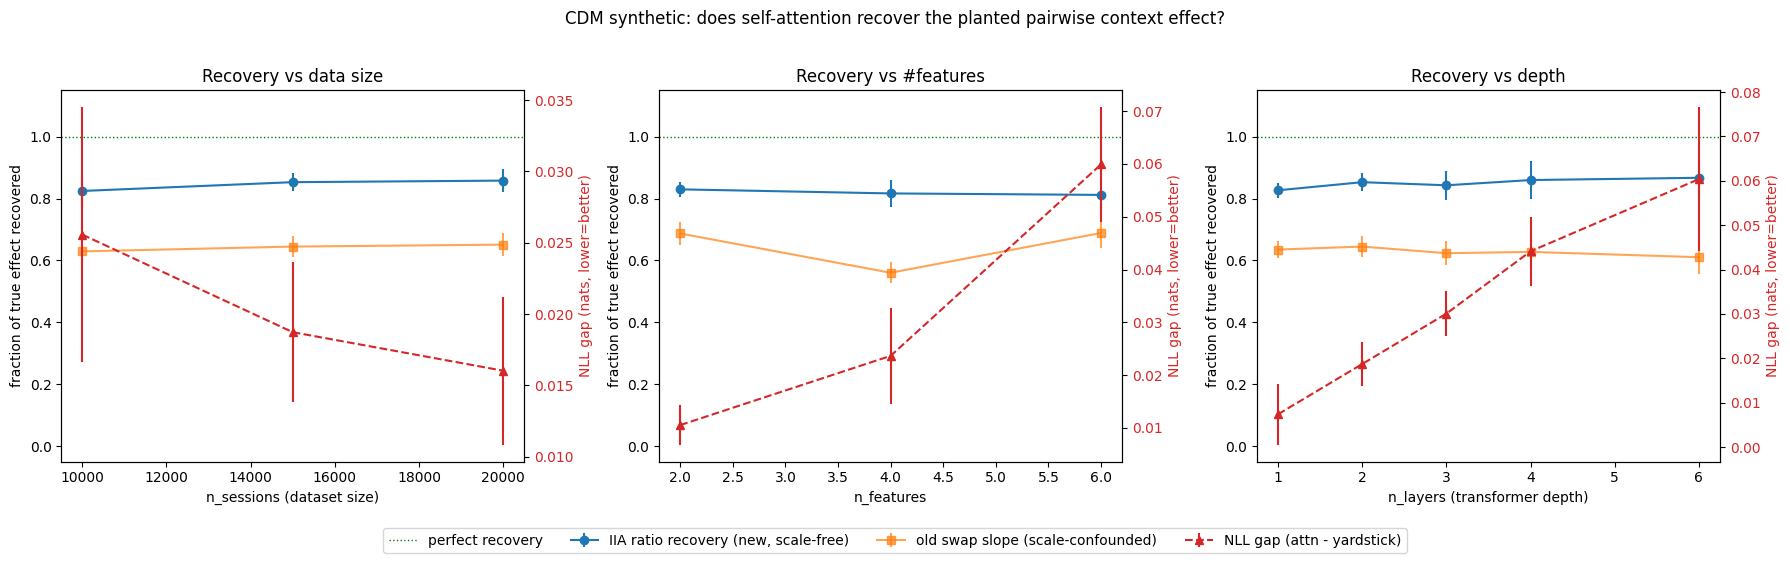

saved cdm_recovery_sweeps.png


In [18]:
import matplotlib.pyplot as plt

def plot_panel(ax, res, xlabel, title):
    x = res["x"]
    ax.errorbar(x, res["iia"][0], yerr=res["iia"][1], marker="o",
                label="IIA ratio recovery (new, scale-free)", color="C0")
    ax.errorbar(x, res["old_slope"][0], yerr=res["old_slope"][1], marker="s",
                label="old swap slope (scale-confounded)", color="C1", alpha=0.7)
    ax.axhline(1.0, ls=":", c="green", lw=1, label="perfect recovery")
    ax.set_xlabel(xlabel); ax.set_ylabel("fraction of true effect recovered")
    ax.set_title(title); ax.set_ylim(-0.05, 1.15)
    ax2 = ax.twinx()
    ax2.errorbar(x, res["nll_gap"][0], yerr=res["nll_gap"][1], marker="^",
                 label="NLL gap (attn - yardstick)", color="C3", ls="--")
    ax2.set_ylabel("NLL gap (nats, lower=better)", color="C3")
    ax2.tick_params(axis="y", labelcolor="C3")
    return ax2

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
a2a = plot_panel(axes[0], res_size,  "n_sessions (dataset size)", "Recovery vs data size")
a2b = plot_panel(axes[1], res_feat,  "n_features",                "Recovery vs #features")
a2c = plot_panel(axes[2], res_depth, "n_layers (transformer depth)", "Recovery vs depth")

# single combined legend
lines, labels = axes[0].get_legend_handles_labels()
l2, lab2 = a2a.get_legend_handles_labels()
fig.legend(lines + l2, labels + lab2, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.08))
plt.suptitle("CDM synthetic: does self-attention recover the planted pairwise context effect?", y=1.02)
plt.tight_layout()
plt.savefig("cdm_recovery_sweeps.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved cdm_recovery_sweeps.png")

## 19. Summary table

Collate every swept point into one tidy dataframe — the exact numbers behind the graphs, ready to drop into the thesis or an appendix. Columns: which axis was varied, its value, and the three metrics (mean over seeds).


In [19]:
def rows_from(res, vary):
    for i, xv in enumerate(res["x"]):
        yield {"swept": vary, "value": xv,
               "iia_recovery": round(res["iia"][0][i], 4),
               "old_slope": round(res["old_slope"][0][i], 4),
               "nll_gap": round(res["nll_gap"][0][i], 4)}

summary = pd.DataFrame(
    list(rows_from(res_size, "n_sessions")) +
    list(rows_from(res_feat, "n_features")) +
    list(rows_from(res_depth, "n_layers"))
)
summary.to_csv("cdm_sweep_summary.csv", index=False)
print(summary.to_string(index=False))
print("\nsaved cdm_sweep_summary.csv")

     swept  value  iia_recovery  old_slope  nll_gap
n_sessions  10000        0.8245     0.6292   0.0256
n_sessions  15000        0.8530     0.6448   0.0187
n_sessions  20000        0.8580     0.6511   0.0160
n_features      2        0.8298     0.6871   0.0105
n_features      4        0.8166     0.5602   0.0236
n_features      6        0.8119     0.6888   0.0599
  n_layers      1        0.8268     0.6352   0.0074
  n_layers      2        0.8530     0.6448   0.0187
  n_layers      3        0.8429     0.6234   0.0301
  n_layers      4        0.8598     0.6276   0.0441
  n_layers      6        0.8671     0.6104   0.0604

saved cdm_sweep_summary.csv


## 20. What this buys us over the old probe

- **Scale-robustness.** The IIA ratio metric can't be fooled by a model that squashes its logit axis — the flaw that made the old slope's "46%" ambiguous. Where the two lines diverge in the graphs, that gap *is* the scale artifact in the old probe.
- **A standard yardstick number.** The NLL gap is the currency the choice-modelling literature (DeepHalo, TCNet, FATE) actually reports, so a reviewer has a reference point for whether it's small.
- **Curves, not a point.** Recovery is now a function of data size, feature count, and depth — so "attention under-recovers" becomes a characterised behaviour rather than one number from one config.

**Suggested next step:** rerun the identical sweep structure on the LCL notebook (feature-weight-bending effect instead of pairwise), then — if you want the behavioural angle — add a decoy/compromise generator and check the model reproduces the *named* effect's reversal, which is the version that reads as serious to a choice-modelling audience.
